In [10]:
%load_ext autoreload
%autoreload 2

import torch
import topofm


torch.set_grad_enabled(False)
DEVICE = "cpu"
DTYPE = torch.float32


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Frames

In [11]:
from topofm.frames import Frame


L = torch.eye(2)
full_eigvals, full_eigvecs = torch.linalg.eigh(L)
eigvals, eigvecs = full_eigvals[:1], full_eigvecs[:, :1]
x = torch.randn(10, 2)
y = torch.randn(10, 1)

frame_in_standard = Frame(eigvecs=eigvecs, ambient='standard')
frame_in_spectral = Frame(eigvecs=eigvecs, ambient='spectral')
frame_in_standard_full = Frame(eigvecs=full_eigvecs, ambient='standard')


assert frame_in_standard.ambient_to_spectral(x).shape == y.shape
assert frame_in_standard_full.ambient_to_spectral(x).shape == x.shape

assert torch.equal(frame_in_spectral.spectral_to_ambient(frame_in_spectral.ambient_to_spectral(y)), y)
assert torch.allclose(frame_in_standard_full.spectral_to_ambient(frame_in_standard_full.ambient_to_spectral(x)), x)

# ODEs

In [12]:
from topofm.odes import TrivialODE, HeatODE
from topofm.frames import Frame


eigvecs = full_eigvecs
eigvals = full_eigvals
frame_in_standard = Frame(eigvecs=eigvecs, ambient='standard')
frame_in_spectral = Frame(eigvecs=eigvecs, ambient='spectral')


trivial_ode = TrivialODE()
kappa = 2.0
heat_ode_in_spectral = HeatODE(kappa=kappa, eigvals=eigvals, frame=frame_in_spectral)
heat_ode_in_standard = HeatODE(kappa=kappa, eigvals=eigvals, frame=frame_in_standard)


x0 = torch.randn(10, 2)
xt = torch.randn(10, 2)
x1 = torch.randn(10, 2)

y0 = frame_in_standard.ambient_to_spectral(x0)
yt = frame_in_standard.ambient_to_spectral(xt)
y1 = frame_in_standard.ambient_to_spectral(x1)

t = torch.tensor(0.5)


assert trivial_ode.x(t=t, x0=x0, x1=x1).shape == xt.shape
assert heat_ode_in_spectral.x(t=t, x0=y0, x1=y1).shape == yt.shape
assert heat_ode_in_standard.x(t=t, x0=x0, x1=x1).shape == xt.shape

assert trivial_ode.b(t=t, xt=xt).shape == xt.shape
assert heat_ode_in_spectral.b(t=t, xt=yt).shape == yt.shape
assert heat_ode_in_standard.b(t=t, xt=xt).shape == xt.shape

assert trivial_ode.v(x0=x0, x1=x1).shape == xt.shape
assert heat_ode_in_spectral.v(x0=y0, x1=y1).shape == yt.shape
assert heat_ode_in_standard.v(x0=x0, x1=x1).shape == xt.shape

assert trivial_ode.sv(t=t, x0=x0, x1=x1).shape == xt.shape
assert heat_ode_in_spectral.sv(t=t, x0=y0, x1=y1).shape == yt.shape
assert heat_ode_in_standard.sv(t=t, x0=x0, x1=x1).shape == xt.shape

assert trivial_ode.c(x0=x0, x1=x1).shape == (*x.shape[:-2], x0.shape[-2], x1.shape[-2])
assert heat_ode_in_spectral.c(x0=y0, x1=y1).shape == (*y.shape[:-2], y0.shape[-2], y1.shape[-2])
assert heat_ode_in_standard.c(x0=x0, x1=x1).shape == (*x.shape[:-2], x0.shape[-2], x1.shape[-2])

# ODE solver

In [13]:
from topofm.odes import Bridge
from topofm.ode_solvers import ODESolver


heat_ode = heat_ode_in_standard


x0 = torch.tensor([-1.0, 1.0])
x1 = torch.tensor([1.0, 1.0])
trivial_bridge = Bridge(ode=trivial_ode, x0=x0, x1=x1)
heat_bridge = Bridge(ode=heat_ode, x0=x0, x1=x1)

n_steps = 100
trivial_bridge_solver = ODESolver(ode=trivial_bridge, n_steps=n_steps)
heat_bridge_solver = ODESolver(ode=heat_bridge, n_steps=n_steps)

assert torch.linalg.norm(trivial_bridge_solver.x1(x0) - x1) < 1e-5
assert torch.linalg.norm(heat_bridge_solver.x1(x0) - x1) < 1e-5

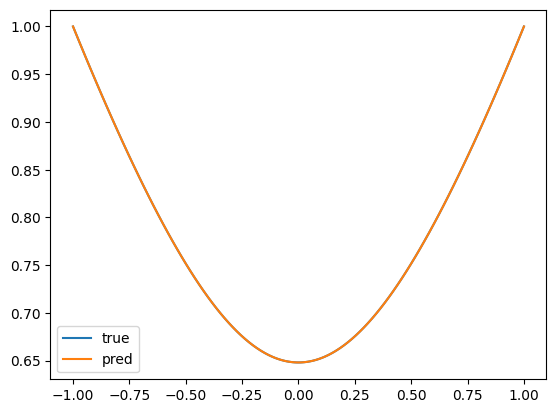

In [14]:
from matplotlib import pyplot as plt


t = torch.linspace(0, 1, n_steps)
true_x = heat_ode.x(t=t[:, None], x0=x0[None], x1=x1[None])
pred_x = heat_bridge_solver.x(x0=x0)


plt.plot(true_x[:, 0], true_x[:, 1], label='true')
plt.plot(pred_x[:, 0], pred_x[:, 1], label='pred')
plt.legend()
plt.show()

# Datasets

In [15]:
from topofm.data.datasets.brain import BrainDataset


brain = BrainDataset.from_disk(device="cpu", ambient='standard', dtype=torch.get_default_dtype())
brain_train, brain_val, brain_test = brain.split()

assert brain_train.mu0.samples.shape[-1] == brain_val.mu0.samples.shape[-1], "Train and validation datasets have different dimensionality"
assert brain_train.mu1.samples.shape[-1] == brain_val.mu1.samples.shape[-1], "Train and validation datasets have different dimensionality"
assert brain_train.mu0.samples.shape[-1] == brain_test.mu0.samples.shape[-1], "Train and test datasets have different dimensionality"
assert brain_train.mu1.samples.shape[-1] == brain_test.mu1.samples.shape[-1], "Train and test datasets have different dimensionality"

# Couplings

In [16]:
from topofm.distributions.boundary import Normal, NodeGP, GP, EmpiricalDistribution
from topofm.couplings import IndependentCoupling, OTCoupling, BatchwiseOTCoupling
from topofm.data.datasets.brain import BrainDataset


dataset = brain
mu0, mu1 = dataset.mu0, dataset.mu1
x0, x1 = mu0.samples, mu1.samples
ode = HeatODE(kappa=1.0, eigvals=dataset.eigvals, frame=dataset.frame)

independent_coupling = IndependentCoupling(mu0, mu1)
exact_ot_coupling = OTCoupling(mu0, mu1, ode=ode, epsilon=0.0)
entropic_ot_coupling = OTCoupling(mu0, mu1, ode=ode, epsilon=0.01)
batchwise_exact_ot_coupling = BatchwiseOTCoupling(mu0, mu1, ode=ode, epsilon=0.0)
batchwise_entropic_ot_coupling = BatchwiseOTCoupling(mu0, mu1, ode=ode, epsilon=0.01)
sample_shape = (7,)

assert exact_ot_coupling.sample(sample_shape)[0].shape == (*sample_shape, mu0.samples.shape[-1])
assert entropic_ot_coupling.sample(sample_shape)[0].shape == (*sample_shape, mu0.samples.shape[-1])
assert batchwise_exact_ot_coupling.sample(sample_shape)[0].shape == (*sample_shape, mu0.samples.shape[-1])
assert batchwise_entropic_ot_coupling.sample(sample_shape)[0].shape == (*sample_shape, mu0.samples.shape[-1])

# Models

In [17]:
from topofm.models import ResidualNN


x = x0
t = torch.ones((x0.shape[0], 1))
dataset = brain
model = ResidualNN(data_dim=dataset.dim, hidden_dim=256, time_embed_dim=128, num_res_block=1)
assert model(t=t, xt=x).shape == x.shape

# Data loaders

In [18]:
from topofm.data.data_loaders import TrainFMDataLoader, TestFMDataLoader


train_dataset, val_dataset, test_dataset = brain_train, brain_val, brain_test 

batch_size = 32
coupling = IndependentCoupling(mu0=train_dataset.mu0, mu1=train_dataset.mu1)
train_loader = TrainFMDataLoader(coupling, batch_size=batch_size, num_samples=train_dataset.num_samples)
val_loader = TestFMDataLoader(val_dataset, batch_size=batch_size)
test_loader = TestFMDataLoader(test_dataset, batch_size=batch_size)

for loader in [train_loader, val_loader, test_loader]:
    for x0, x1 in loader:
        assert x0.shape == (batch_size, train_dataset.dim)
        assert x1.shape == (batch_size, train_dataset.dim)

# Callbacks

In [19]:
from topofm.callbacks import EarlyStopping, ModelCheckpoint


early_stopping = EarlyStopping(enabled=False, monitor="w2")
model_checkpoint = ModelCheckpoint(enabled=False, monitor="w2", dirpath="./checkpoints/", filename="model.pt")

# Loggers

In [20]:
from topofm.loggers import WandbLogger

logger = WandbLogger(enabled=False, project="test", entity="test", run_name="test", config={})

# Flow-matching loss

In [21]:
from topofm.metrics.fm_loss import FMLoss
from topofm.distributions.time import GridTimeDistribution


time_distribution = GridTimeDistribution(n=100, device=DEVICE, dtype=DTYPE)
fm_loss = FMLoss(ode=ode, model=model, time_distribution=time_distribution)

loss = fm_loss(x0, x1)
assert loss.shape == ()
assert loss > 0

# Training loop

In [22]:
from topofm.models import Model
from torch.optim import Optimizer
from topofm.loggers import Logger
from tqdm import tqdm


def train(
    model: Model,
    solver: ODESolver,
    train_loader: TrainFMDataLoader,
    val_loader: TestFMDataLoader,
    optimizer: Optimizer,
    early_stopping: EarlyStopping,
    model_checkpoint: ModelCheckpoint,
    logger: Logger,
    criterion: FMLoss,
    val_frequency: int | None = None,
) -> None:
    if val_frequency is None:
        val_frequency = torch.inf

    model.train()
    pbar = tqdm(train_loader, desc="Training")
    samples_processed = 0
    next_val_threshold = val_frequency
    
    for x0, x1 in pbar:
        # Optimization Step
        optimizer.zero_grad()
        loss = criterion(x0, x1)
        loss.backward()
        optimizer.step()
        
        samples_processed += len(x0)
        pbar.set_postfix({"loss": loss.item()})

        # --- G. Validation & Callbacks ---
        if samples_processed >= next_val_threshold:
            model.eval()
            
            # Run validation
            metrics = validate(model, solver, val_loader)
            
            model.train()

            # Log metrics to TensorBoard/WandB
            logger.log(metrics)
            print(metrics['w2'])

            # Explicit Callback Calls
            model_checkpoint.save_if_best(model, metrics, step=samples_processed)
            early_stopping.check(metrics)
            
            if early_stopping.should_stop:
                if fabric.global_rank == 0:
                    log.info("Stopping training due to EarlyStopping.")
                break

            next_val_threshold += val_frequency


from topofm.metrics.wasserstein_distance import wasserstein_distance
from topofm.odes import NeuralODE


@torch.inference_mode()
def validate(
    model: Model, 
    ode_solver: ODESolver,
    data_loader: TestFMDataLoader,
) -> dict[str, float]:
    neural_ode = NeuralODE(base_ode=ode_solver.ode, model=model)
    solver = ODESolver(neural_ode, n_steps=ode_solver.n_steps)

    model.eval()
    # Predict x1 from x0
    x1_pred, x1 = [], []
    for x0_batch, x1_batch in data_loader:
        x1_pred.append(solver.x1(x0_batch))
        x1.append(x1_batch)
    x1_pred = torch.cat(x1_pred, dim=0)
    x1 = torch.cat(x1, dim=0)

    # Compute validation metrics
    metrics = {
        "w1": wasserstein_distance(x1_pred, x1, p=1, epsilon=0.05),
        "w2": wasserstein_distance(x1_pred, x1, p=2, epsilon=0.05),
        "w1_exact": wasserstein_distance(x1_pred, x1, p=1, epsilon=0.0),
        "w2_exact": wasserstein_distance(x1_pred, x1, p=2, epsilon=0.0),
    }
    return metrics

In [28]:
from topofm.distributions.time import UniformTimeDistribution
from topofm.data.datasets.brain import BrainDataset


torch.set_grad_enabled(True)

# Callbacks
early_stopping = EarlyStopping(enabled=False, monitor='w2')
model_checkpoint = ModelCheckpoint(enabled=False, monitor='w2', dirpath='./', filename='model.pt')
logger = WandbLogger(False, '', '', '', {})


# Dataset
dataset = BrainDataset.from_disk(ambient='standard', device=DEVICE, dtype=DTYPE)
train_dataset, val_dataset, test_dataset = dataset.split()
# coupling = IndependentCoupling(mu0=train_dataset.mu0, mu1=train_dataset.mu1)
coupling = OTCoupling(mu0=train_dataset.mu0, mu1=train_dataset.mu1, ode=ode, epsilon=0.0)


# ODE
kappa = 2.0
ode = HeatODE(kappa=kappa, eigvals=dataset.eigvals, frame=dataset.frame)
# ode = TrivialODE()

# ODESolver
ode_solver = ODESolver(ode=ode, n_steps=100)

# Model 
mode = 'sv'
model = ResidualNN(data_dim=dataset.dim, mode=mode)

# Loss
time_distribution = UniformTimeDistribution(device=DEVICE, dtype=DTYPE)
fm_loss = FMLoss(ode=ode, model=model, time_distribution=time_distribution)


# Loaders
train_loader = TrainFMDataLoader(coupling=coupling, batch_size=128, num_samples=100 * train_dataset.num_samples)
val_loader = TestFMDataLoader(dataset=val_dataset)
test_loader = TestFMDataLoader(test_dataset)

optimizer = torch.optim.AdamW(model.parameters(), lr=0.0001)
criterion = fm_loss
val_frequency = None

train(
    model=model,
    solver=ode_solver,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    early_stopping=early_stopping,
    model_checkpoint=model_checkpoint,
    logger=logger,
    val_frequency=val_frequency,
    criterion=criterion,
)
validate(
    model=model, 
    ode_solver=ode_solver, 
    data_loader=test_loader,
)

Training: 650it [00:04, 145.62it/s, loss=0.136]


{'w1': 5.869245529174805,
 'w2': 4.108727001547096,
 'w1_exact': 5.957344884247124,
 'w2_exact': 6.088842728777803}